In [13]:
import os   
import pandas as pd
import numpy as np

In [14]:
os.chdir("/Users/shubhamfufal/Documents/SkillShelf") 
print(os.getcwd())

/Users/shubhamfufal/Documents/SkillShelf


In [15]:
coursera = pd.read_csv("SkillShelfBackend/recommender/data/Coursera.csv")
edx = pd.read_csv("SkillShelfBackend/recommender/data/Edx.csv")
udacity = pd.read_csv("SkillShelfBackend/recommender/data/Udacity.csv")

In [17]:
coursera["origin"] = "Coursera"
edx["origin"] = "Edx"
udacity["origin"] = "Udacity"

In [18]:
df = pd.concat([coursera, edx, udacity], ignore_index = True)

In [19]:
df.columns 

Index(['Course Name', 'University', 'Difficulty Level', 'Course Rating',
       'Course URL', 'Course Description', 'Skills', 'origin', 'Name', 'Link',
       'About', 'School', 'Rating'],
      dtype='object')

In [20]:
df.columns = [col.lower().replace(" ", "_") for col in df.columns]

In [21]:
df.columns

Index(['course_name', 'university', 'difficulty_level', 'course_rating',
       'course_url', 'course_description', 'skills', 'origin', 'name', 'link',
       'about', 'school', 'rating'],
      dtype='object')

In [26]:
df.dtypes

course_name            object
university             object
difficulty_level       object
course_rating          object
course_url             object
course_description     object
skills                 object
origin                 object
name                   object
link                   object
about                  object
school                 object
rating                float64
dtype: object

In [27]:
textCols = ["name", "university", "about", "course_description", "skills"]

In [28]:
for col in textCols:
    if col in df.columns:
        df[col] = df[col].fillna("unknown")
        df[col] = df[col].astype(str)

In [30]:
df.dtypes

course_name            object
university             object
difficulty_level       object
course_rating          object
course_url             object
course_description     object
skills                 object
origin                 object
name                   object
link                   object
about                  object
school                 object
rating                float64
dtype: object

In [38]:
df.isna().sum()

course_name            983
university               0
difficulty_level         4
course_rating          983
course_url             983
course_description       0
skills                   0
origin                   0
name                     0
link                  3522
about                    0
school                4242
rating                4450
dtype: int64

In [43]:
df = df.dropna(subset = ["course_name"])

In [44]:
df.head()

,course_name,university,difficulty_level,course_rating,course_url,course_description,skills,origin,name,link,about,school,rating
0,Write A Feature Length Screenplay For Film Or ...,Michigan State University,Beginner,4.8,https://www.coursera.org/learn/write-a-feature...,Write a Full Length Feature Film Script In th...,Drama Comedy peering screenwriting film D...,Coursera,unknown,NaN,unknown,NaN,NaN
1,Business Strategy: Business Model Canvas Analy...,Coursera Project Network,Beginner,4.8,https://www.coursera.org/learn/canvas-analysis...,"By the end of this guided project, you will be...",Finance business plan persona (user experien...,Coursera,unknown,NaN,unknown,NaN,NaN
2,Silicon Thin Film Solar Cells,�cole Polytechnique,Advanced,4.1,https://www.coursera.org/learn/silicon-thin-fi...,This course consists of a general presentation...,chemistry physics Solar Energy film lambda...,Coursera,unknown,NaN,unknown,NaN,NaN
3,Finance for Managers,IESE Business School,Intermediate,4.8,https://www.coursera.org/learn/operational-fin...,"When it comes to numbers, there is always more...",accounts receivable dupont analysis analysis...,Coursera,unknown,NaN,unknown,NaN,NaN
4,Retrieve Data using Single-Table SQL Queries,Coursera Project Network,Beginner,4.6,https://www.coursera.org/learn/single-table-sq...,In this course you�ll learn how to effectively...,Data Analysis select (sql) database manageme...,Coursera,unknown,NaN,unknown,NaN,NaN


In [45]:
df.isna().sum()

course_name              0
university               0
difficulty_level         0
course_rating            0
course_url               0
course_description       0
skills                   0
origin                   0
name                     0
link                  3522
about                    0
school                3522
rating                3522
dtype: int64

In [71]:
df["link"] = df["link"].fillna("unknown")
df["school"] = df["school"].fillna("unknown")
df["rating"] = df["rating"].fillna(0)

In [47]:
df.isna().sum()

course_name           0
university            0
difficulty_level      0
course_rating         0
course_url            0
course_description    0
skills                0
origin                0
name                  0
link                  0
about                 0
school                0
rating                0
dtype: int64

In [48]:
import re

In [49]:
def cleanText(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r"[^a-z0-9\s]", "", text)
        text = re.sub(r"\s+", " ", text).strip()
    return text

In [50]:
textColumns = ["course_name", "university", "course_description"]

for col in textColumns:
    df[col] = df[col].apply(cleanText)

/var/folders/l0/qjs1gw_97gzdg8wrkw2bt6gh0000gn/T/ipykernel_5929/3238101700.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].apply(cleanText)


In [51]:
df.head()

,course_name,university,difficulty_level,course_rating,course_url,course_description,skills,origin,name,link,about,school,rating
0,write a feature length screenplay for film or ...,michigan state university,Beginner,4.8,https://www.coursera.org/learn/write-a-feature...,write a full length feature film script in thi...,Drama Comedy peering screenwriting film D...,Coursera,unknown,unknown,unknown,unknown,unknown
1,business strategy business model canvas analys...,coursera project network,Beginner,4.8,https://www.coursera.org/learn/canvas-analysis...,by the end of this guided project you will be ...,Finance business plan persona (user experien...,Coursera,unknown,unknown,unknown,unknown,unknown
2,silicon thin film solar cells,cole polytechnique,Advanced,4.1,https://www.coursera.org/learn/silicon-thin-fi...,this course consists of a general presentation...,chemistry physics Solar Energy film lambda...,Coursera,unknown,unknown,unknown,unknown,unknown
3,finance for managers,iese business school,Intermediate,4.8,https://www.coursera.org/learn/operational-fin...,when it comes to numbers there is always more ...,accounts receivable dupont analysis analysis...,Coursera,unknown,unknown,unknown,unknown,unknown
4,retrieve data using singletable sql queries,coursera project network,Beginner,4.6,https://www.coursera.org/learn/single-table-sq...,in this course youll learn how to effectively ...,Data Analysis select (sql) database manageme...,Coursera,unknown,unknown,unknown,unknown,unknown


In [52]:
df = df.drop_duplicates(subset = ["course_name"], keep = "first")
print(f"Remaining duplicates: {df.duplicated().sum()}")

Remaining duplicates: 0


In [53]:
df["description_word_count"] = df["course_description"].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)

In [56]:
!pip install matplotlib

5390.40s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.7-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.2.0-py3-none-any.whl.metadata (5.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 4.8 MB/s eta 0:00:00a 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 4.7 MB/s eta 0:00:00a 0:00:01
Using cached kiwisolver-1.4.7-cp312-cp312-macosx_11_0_arm64.whl (63 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 8.2 MB/s eta 0:00:00a 0:00:01
Using cached pyparsing-3.2.0-py3-none-any.whl (106 kB)


In [58]:
!pip install seaborn

5424.87s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

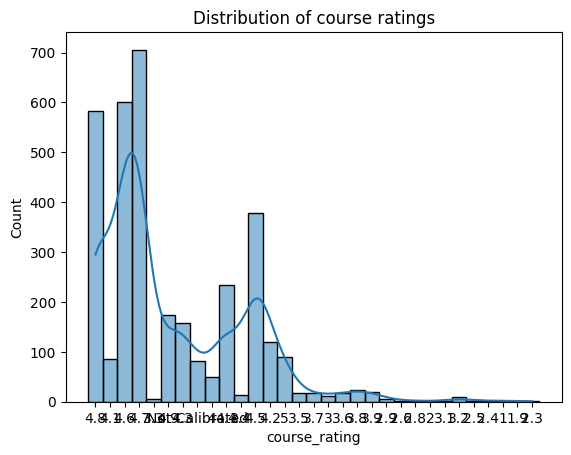

In [61]:
sns.histplot(df["course_rating"], kde = True)
plt.title("Distribution of course ratings")
plt.show()

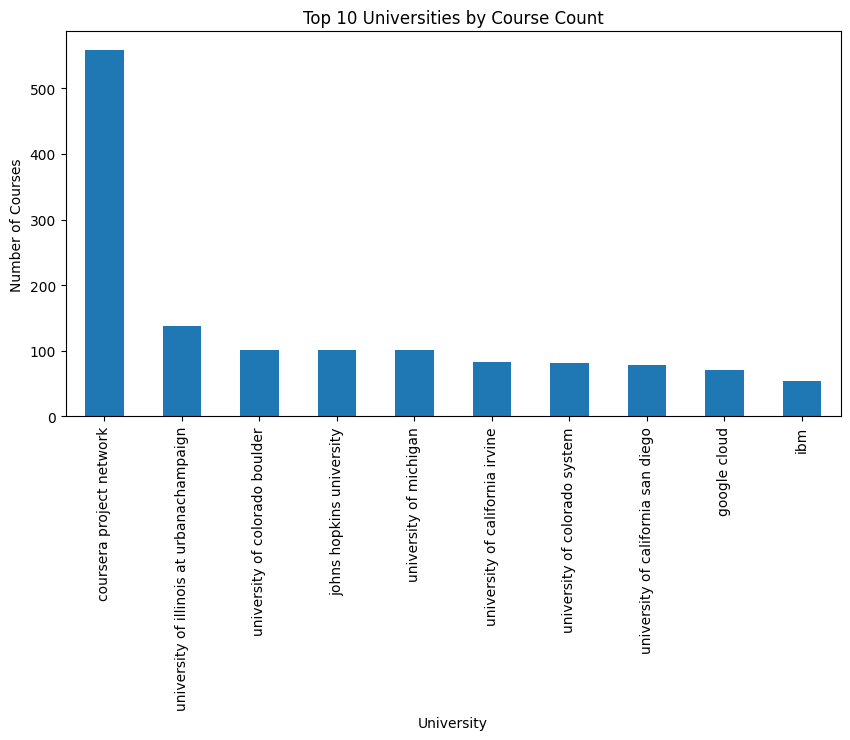

In [62]:
df["university"].value_counts().head(10).plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 Universities by Course Count")
plt.xlabel("University")
plt.ylabel("Number of Courses")
plt.show()


In [63]:
df["skills"] = df["skills"].apply(lambda x: x.split(",") if isinstance(x, str) else [])

In [65]:
from itertools import chain
uniqueSkills = set(chain(*df["skills"]))
print(f"Number of unique skills: {len(uniqueSkills)})")
print(list(uniqueSkills)[:10])

Number of unique skills: 3416)
['thought  history  interpretation  plantation  man  ageing  constitution  quoting out of context  future generation  religion arts-and-humanities history', 'active management  corporate bond  value proposition  modeling  organizing (management)  Entrepreneurship  Customer Relationship Management  business case  Strategy  Innovation business entrepreneurship', 'infection  public health  Microsoft Excel  social epidemiology  immunology  outbreak  Epidemiology  hiv/aids  contact tracing  hiv life-sciences public-health', 'principal agent problem  payment systems  incentive  market (economics)  health insurance  health system  health care  competition law  health care reform  consumer choice life-sciences healthcare-management', 'Causality  denial  ethics  sociology  religion  relative change and difference  philosophy  Anthropology  skepticism  climate change skepticism and denial arts-and-humanities philosophy', 'project  Cloud Computing  interfaces  inter

In [66]:
df["about_length"] = df["about"].apply(len)
df["course_description_length"] = df["course_description"].apply(len)

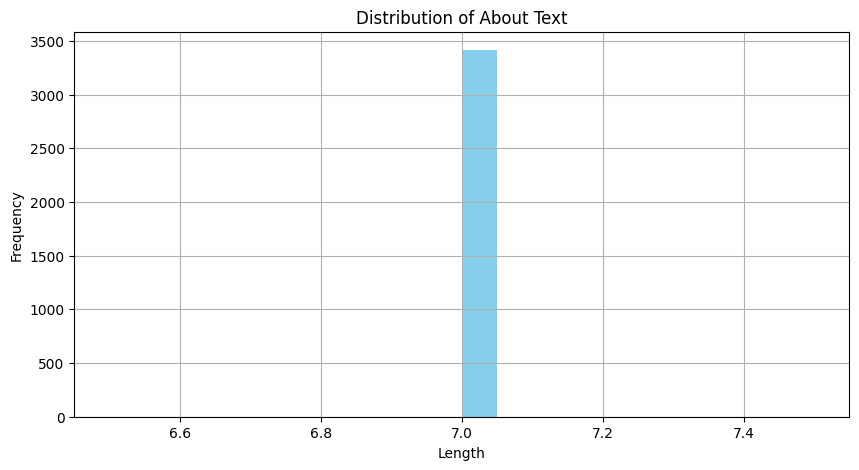

In [67]:
df["about_length"].hist(bins = 20, figsize = (10, 5), color = "skyblue")
plt.title("Distribution of About Text")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

In [72]:
print(df[["rating", "difficulty_level"]].corr())

ValueError: could not convert string to float: 'unknown'

In [77]:
df["rating"].unique()

array(['unknown'], dtype=object)

In [78]:
df["difficulty_level"].unique()

array(['Beginner', 'Advanced', 'Intermediate', 'Not Calibrated',
       'Conversant'], dtype=object)

In [74]:
df["difficulty_level"].value_counts()

difficulty_level
Beginner          1401
Advanced           989
Intermediate       822
Conversant         154
Not Calibrated      50
Name: count, dtype: int64


In [79]:
df["rating"] = pd.to_numeric(df["rating"], errors = "coerce")
df["rating"].fillna(0, inplace = True)

/var/folders/l0/qjs1gw_97gzdg8wrkw2bt6gh0000gn/T/ipykernel_5929/1942033143.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["rating"].fillna(0, inplace = True)


In [83]:
difficulty_map = {
    "Beginner": 1,
    "Intermediate": 2,
    "Advanced": 3,
    "Not Calibrated": 0,
    "Conversant": 4,
}
df["difficulty_level_encoded"] = df["difficulty_level"].map(difficulty_map)

In [84]:
df[["rating", "difficulty_level_encoded"]].corr()

,rating,difficulty_level_encoded
rating,NaN,NaN
difficulty_level_encoded,NaN,1.0


In [85]:
df.head()

,course_name,university,difficulty_level,course_rating,course_url,course_description,skills,origin,name,link,about,school,rating,description_word_count,about_length,course_description_length,difficulty_level_encoded
0,write a feature length screenplay for film or ...,michigan state university,Beginner,4.8,https://www.coursera.org/learn/write-a-feature...,write a full length feature film script in thi...,[Drama Comedy peering screenwriting film ...,Coursera,unknown,unknown,unknown,unknown,0.0,437,7,2490,1
1,business strategy business model canvas analys...,coursera project network,Beginner,4.8,https://www.coursera.org/learn/canvas-analysis...,by the end of this guided project you will be ...,[Finance business plan persona (user experie...,Coursera,unknown,unknown,unknown,unknown,0.0,113,7,730,1
2,silicon thin film solar cells,cole polytechnique,Advanced,4.1,https://www.coursera.org/learn/silicon-thin-fi...,this course consists of a general presentation...,[chemistry physics Solar Energy film lambd...,Coursera,unknown,unknown,unknown,unknown,0.0,245,7,1712,3
3,finance for managers,iese business school,Intermediate,4.8,https://www.coursera.org/learn/operational-fin...,when it comes to numbers there is always more ...,[accounts receivable dupont analysis analysi...,Coursera,unknown,unknown,unknown,unknown,0.0,89,7,550,2
4,retrieve data using singletable sql queries,coursera project network,Beginner,4.6,https://www.coursera.org/learn/single-table-sq...,in this course youll learn how to effectively ...,[Data Analysis select (sql) database managem...,Coursera,unknown,unknown,unknown,unknown,0.0,300,7,1649,1


In [88]:
df.to_csv("SkillShelfBackend/recommender/data/PreprocessedDataset.csv", index = False)

In [87]:
os.getcwd()

'/Users/shubhamfufal/Documents/SkillShelf'

In [89]:
os.makedirs("dataNew", exist_ok=True)